Data set = https://www.kaggle.com/competitions/GiveMeSomeCredit/data?select=cs-training.csv

**Problem Statement**

A bank wants to automate loan approval decisions. Build a decision tree classifier to predict which loan
applicants are likely to default, helping the bank minimize credit risk while approving creditworthy customers.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
roc_auc_score)
import warnings
warnings.filterwarnings('ignore')


In [19]:
 #1. LOAD DATA
df = pd.read_csv("/content/cs-training.csv", index_col=0)
print(df.shape)
print("Default rate:", df['SeriousDlqin2yrs'].mean())

(150000, 11)
Default rate: 0.06684


In [20]:
# 2. CLEAN DATA
# Cap extreme outliers at 99th percentile
for col in ['RevolvingUtilizationOfUnsecuredLines', 'DebtRatio', 'MonthlyIncome']:
 cap = df[col].quantile(0.99)
df[col] = df[col].clip(upper=cap)
# Impute missing values
df['MonthlyIncome'].fillna(df['MonthlyIncome'].median(), inplace=True)
df['NumberOfDependents'].fillna(df['NumberOfDependents'].median(), inplace=True)


In [21]:
# 3. PREPARE FEATURES
X = df.drop('SeriousDlqin2yrs', axis=1)
y = df['SeriousDlqin2yrs']
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y
)


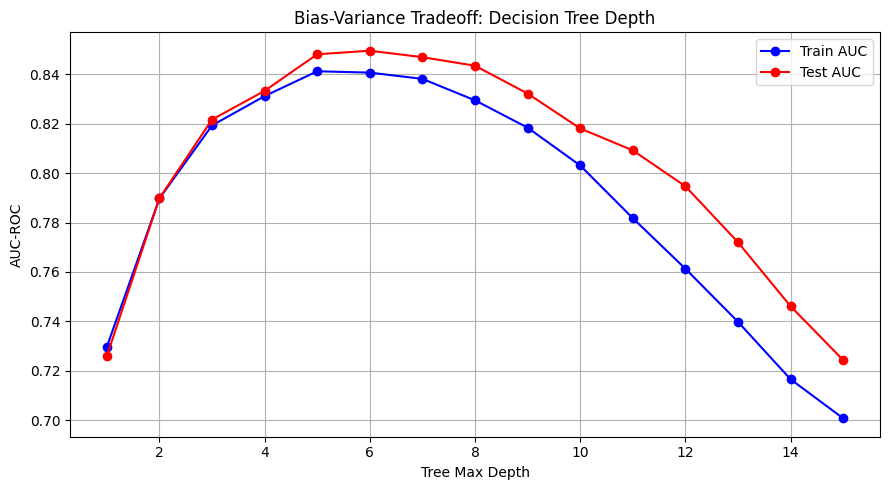

Best depth: 6


In [22]:
#4. FIND OPTIMAL DEPTH
train_scores, test_scores = [], []
depths = range(1, 16)

for d in depths:
    tree = DecisionTreeClassifier(
        max_depth=d,
        class_weight='balanced',
        random_state=42
    )

    train_score = cross_val_score(
        tree, X_train, y_train,
        cv=5,
        scoring='roc_auc'
    ).mean()

    tree.fit(X_train, y_train)

    test_score = roc_auc_score(
        y_test,
        tree.predict_proba(X_test)[:, 1]
    )

    train_scores.append(train_score)
    test_scores.append(test_score)

# Plot learning curve
plt.figure(figsize=(9, 5))
plt.plot(depths, train_scores, 'b-o', label='Train AUC')
plt.plot(depths, test_scores, 'r-o', label='Test AUC')
plt.xlabel("Tree Max Depth")
plt.ylabel("AUC-ROC")
plt.title("Bias-Variance Tradeoff: Decision Tree Depth")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("depth_tuning.png", dpi=150)
plt.show()

# Best depth
best_depth = list(depths)[np.argmax(test_scores)]
print(f"Best depth: {best_depth}")

In [23]:
# 5. FINAL MODEL
model = DecisionTreeClassifier(max_depth=best_depth,
class_weight='balanced', random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")




=== Classification Report ===
              precision    recall  f1-score   support

           0       0.98      0.79      0.87     27995
           1       0.21      0.77      0.32      2005

    accuracy                           0.78     30000
   macro avg       0.59      0.78      0.60     30000
weighted avg       0.93      0.78      0.84     30000

AUC-ROC: 0.8495


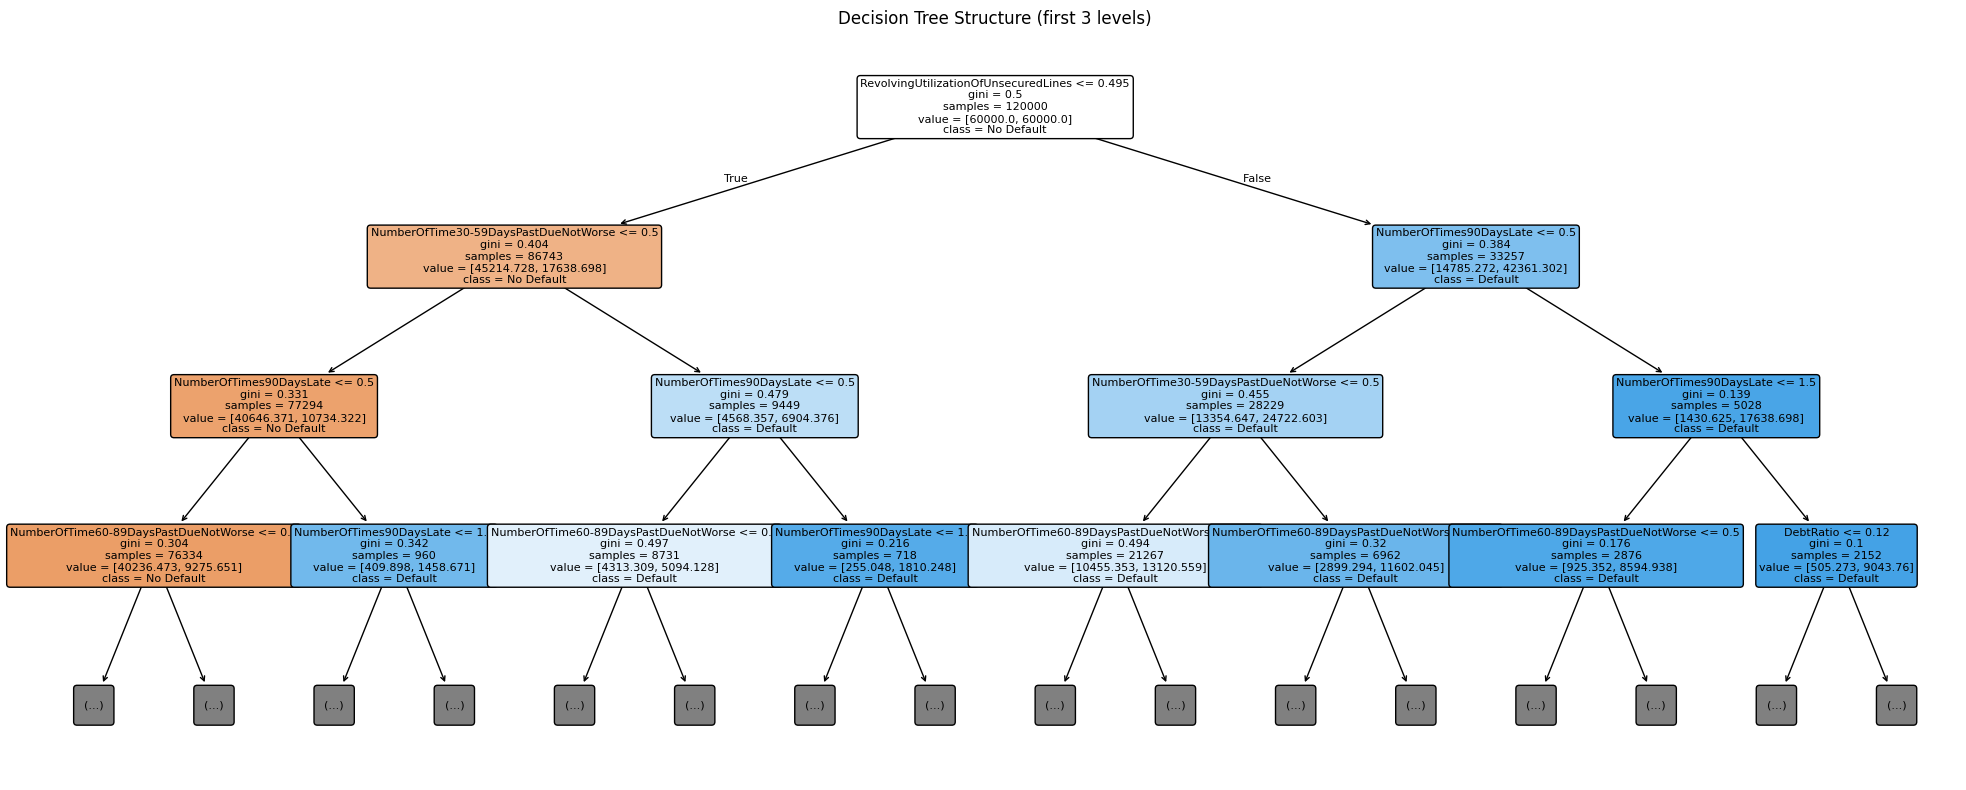

In [24]:
# 6. VISUALIZE TREE
plt.figure(figsize=(20, 8))
plot_tree(model, feature_names=X.columns, class_names=['No Default', 'Default'],
filled=True, rounded=True, max_depth=3, fontsize=8)
plt.title("Decision Tree Structure (first 3 levels)")
plt.tight_layout()
plt.savefig("decision_tree.png", dpi=150)
plt.show()

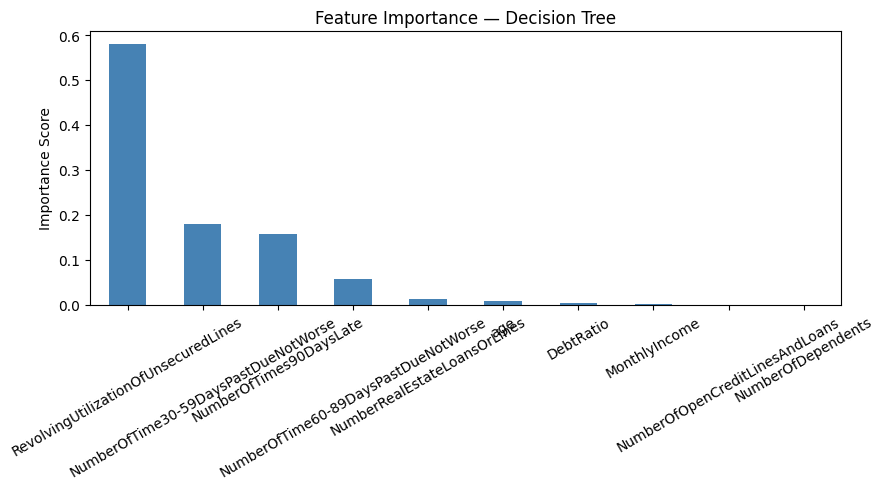

In [25]:
# 7. FEATURE IMPORTANCE
fi = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(9, 5))
fi.plot(kind='bar', color='steelblue')
plt.title("Feature Importance — Decision Tree")
plt.ylabel("Importance Score")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

**Key Insights & Business Implications **

Credit utilization is the strongest predictor of default — Higher RevolvingUtilizationOfUnsecuredLines indicates over-dependence on credit.
→ Action: Set stricter credit limits or trigger early warning alerts for customers with high utilization ratios.


Past delinquency is a critical risk indicator — NumberOfTime30-59DaysPastDueNotWorse strongly correlates with future defaults.
→ Action: Prioritize such customers for risk monitoring, reduce loan approvals, or apply higher interest rates.


Severe class imbalance (~6.7% defaults) — Model may ignore risky customers without proper handling.
→ Action: Use class_weight=balanced or resampling techniques to improve recall for default prediction.

Optimal model depth is 5–7 — Deeper trees overfit and reduce real-world performance.
→ Action: Deploy controlled-complexity models to ensure better generalization on unseen data.

Higher default rate in customers under 30 — Indicates risk associated with younger demographics.
→ Action: Apply stricter credit policies, lower initial limits, or financial education programs for younger customers.